In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
%matplotlib inline


In [79]:
train=pd.read_csv('C:/Users/umman/Downloads/train.csv')
test=pd.read_csv('C:/Users/umman/Downloads/test.csv')
oil=pd.read_csv('C:/Users/umman/Downloads/oil.csv')
store=pd.read_csv('C:/Users/umman/Downloads/stores.csv')
holiday=pd.read_csv('C:/Users/umman/Downloads/holidays_events.csv')
transactions=pd.read_csv('C:/Users/umman/Downloads/transactions.csv')

In [80]:
train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [81]:
test.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [82]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [83]:
store.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [84]:
holiday.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [85]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [86]:
train=pd.merge(train,oil,how='left',on="date")
test=pd.merge(test,oil,how='left',on="date")

In [87]:
train=pd.merge(train,store,how='left',on="store_nbr")
test=pd.merge(test,store,how='left',on="store_nbr")

In [88]:
train=pd.merge(train,holiday,how='left',on="date")
test=pd.merge(test,holiday,how='left',on="date")

In [89]:
train=pd.merge(train,transactions,how='left',on=["date","store_nbr"])
test=pd.merge(test,transactions,how='left',on=["date","store_nbr"])

In [90]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN


In [91]:
train=train.rename(columns={"type_x":"store_type"
                     ,"type_y":"holiday_type"})
test=test.rename(columns={"type_x":"store_type"
                     ,"type_y":"holiday_type"})

In [92]:
train.isna().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
dcoilwtico       955152
city                  0
state                 0
store_type            0
cluster               0
holiday_type    2551824
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
transactions     249117
dtype: int64

In [93]:
train['transactions']=train['transactions'].fillna(0)
test['transactions']=test['transactions'].fillna(0)

In [94]:
train = train.sort_values('date')
test = test.sort_values('date')

In [95]:
train['dcoilwtico'] = (
    train['dcoilwtico']
      .interpolate()
      .ffill()
      .bfill()
)
test['dcoilwtico'] = (
    test['dcoilwtico']
      .interpolate()
      .ffill()
      .bfill()
)

In [96]:
train['transferred']=train['transferred'].fillna(False)
test['transferred']=test['transferred'].fillna(False)

In [97]:
train.drop(columns=['description'], inplace=True)
test.drop(columns=['description'], inplace=True)


In [98]:
train[train['city'] == train['locale_name']]

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,store_type,cluster,holiday_type,locale,locale_name,transferred,transactions
108536,108536,2013-03-02,53,SEAFOOD,0.000,0,90.628654,Manta,Manabi,D,13,Holiday,Local,Manta,False,0.0
108535,108535,2013-03-02,53,SCHOOL AND OFFICE SUPPLIES,0.000,0,90.628491,Manta,Manabi,D,13,Holiday,Local,Manta,False,0.0
108506,108506,2013-03-02,53,BEAUTY,0.000,0,90.628328,Manta,Manabi,D,13,Holiday,Local,Manta,False,0.0
108505,108505,2013-03-02,53,BABY CARE,0.000,0,90.628165,Manta,Manabi,D,13,Holiday,Local,Manta,False,0.0
108504,108504,2013-03-02,53,AUTOMOTIVE,0.000,0,90.628003,Manta,Manabi,D,13,Holiday,Local,Manta,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3052758,2999298,2017-08-15,14,PLAYERS AND ELECTRONICS,13.000,0,47.570000,Riobamba,Chimborazo,C,7,Holiday,Local,Riobamba,False,1241.0
3052763,2999303,2017-08-15,14,SEAFOOD,6.000,0,47.570000,Riobamba,Chimborazo,C,7,Holiday,Local,Riobamba,False,1241.0
3052762,2999302,2017-08-15,14,SCHOOL AND OFFICE SUPPLIES,4.000,3,47.570000,Riobamba,Chimborazo,C,7,Holiday,Local,Riobamba,False,1241.0
3052761,2999301,2017-08-15,14,PRODUCE,551.648,88,47.570000,Riobamba,Chimborazo,C,7,Holiday,Local,Riobamba,False,1241.0


In [99]:
#creating a new column where if the condition matches for the holiday and the city, it gives a 1
train['is_holiday'] = (
    (train['locale'] == 'National') & train['locale'].notna() | 
    (train['locale'] == 'Regional') & (train['city'] == train['locale_name']) |
    (train['locale'] == 'Local') & (train['city'] == train['locale_name'])
).astype(int)
test['is_holiday'] = (
    (test['locale'] == 'National') & test['locale'].notna() | 
    (test['locale'] == 'Regional') & (test['city'] == test['locale_name']) |
    (test['locale'] == 'Local') & (test['city'] == test['locale_name'])
).astype(int)

In [100]:
train['is_holiday'] = ((train['holiday_type'].notna()) & (~train['transferred'])).astype(int)
test['is_holiday'] = ((test['holiday_type'].notna()) & (~test['transferred'])).astype(int)

In [101]:
train.drop(columns=['holiday_type'],inplace=True)
test.drop(columns=['holiday_type'],inplace=True)

In [102]:
train.drop(columns=['locale','locale_name'],inplace=True)
test.drop(columns=['locale','locale_name'],inplace=True)

In [103]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,store_type,cluster,transferred,transactions,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13,False,0.0,1
1194,1194,2013-01-01,42,CELEBRATION,0.0,0,93.14,Cuenca,Azuay,D,2,False,0.0,1
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,93.14,Cuenca,Azuay,D,2,False,0.0,1
1192,1192,2013-01-01,42,BOOKS,0.0,0,93.14,Cuenca,Azuay,D,2,False,0.0,1
1191,1191,2013-01-01,42,BEVERAGES,0.0,0,93.14,Cuenca,Azuay,D,2,False,0.0,1


In [150]:
test.head()

,date,id,store_nbr,family,city,state,store_type,cluster,transactions,onpromotion,dcoilwtico,transferred,is_holiday
0,2017-08-16,3000888,1,AUTOMOTIVE,Quito,Pichincha,D,13,0.0,0,46.8,0,0
1194,2017-08-16,3002082,42,CELEBRATION,Cuenca,Azuay,D,2,0.0,0,46.8,0,0
1193,2017-08-16,3002081,42,BREAD/BAKERY,Cuenca,Azuay,D,2,0.0,12,46.8,0,0
1192,2017-08-16,3002080,42,BOOKS,Cuenca,Azuay,D,2,0.0,0,46.8,0,0
1191,2017-08-16,3002079,42,BEVERAGES,Cuenca,Azuay,D,2,0.0,19,46.8,0,0


In [104]:
train.isna().sum()

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
dcoilwtico      0
city            0
state           0
store_type      0
cluster         0
transferred     0
transactions    0
is_holiday      0
dtype: int64

In [105]:
train['transferred'] = train['transferred'].astype(int)
test['transferred'] = test['transferred'].astype(int)
#automatically converts false to 0 and true to 1

In [106]:
train=train[train['sales']<50000]

In [107]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,store_type,cluster,transferred,transactions,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13,0,0.0,1
1194,1194,2013-01-01,42,CELEBRATION,0.0,0,93.14,Cuenca,Azuay,D,2,0,0.0,1
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,93.14,Cuenca,Azuay,D,2,0,0.0,1
1192,1192,2013-01-01,42,BOOKS,0.0,0,93.14,Cuenca,Azuay,D,2,0,0.0,1
1191,1191,2013-01-01,42,BEVERAGES,0.0,0,93.14,Cuenca,Azuay,D,2,0,0.0,1


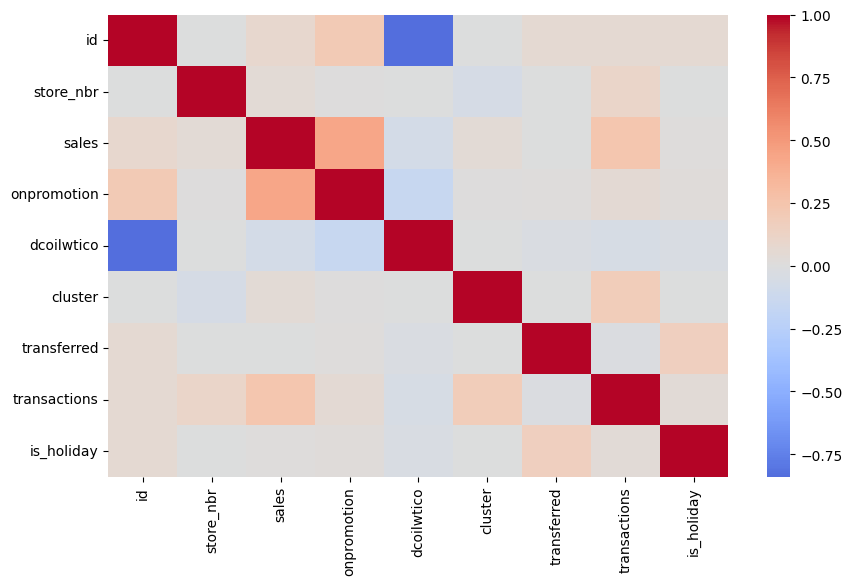

In [108]:

num_cols = train.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

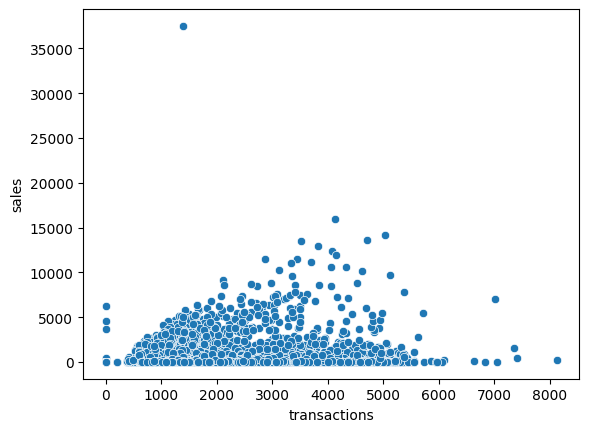

In [109]:
sample_df = train.sample(n=10000, random_state=42)
sns.scatterplot(data=sample_df, x='transactions', y='sales')
plt.show()


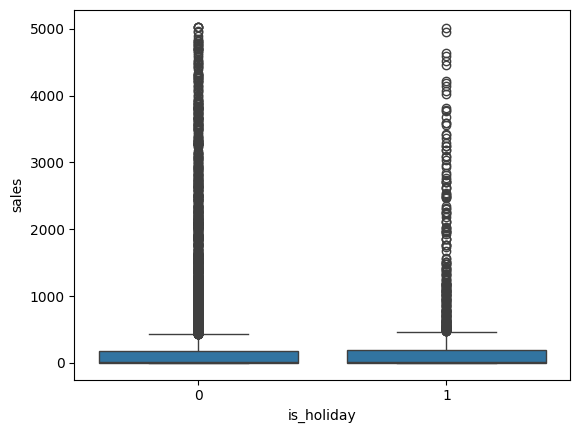

In [110]:
filtered = sample_df[sample_df['sales'] < sample_df['sales'].quantile(0.99)]

sns.boxplot(x='is_holiday', y='sales', data=filtered)
plt.show()


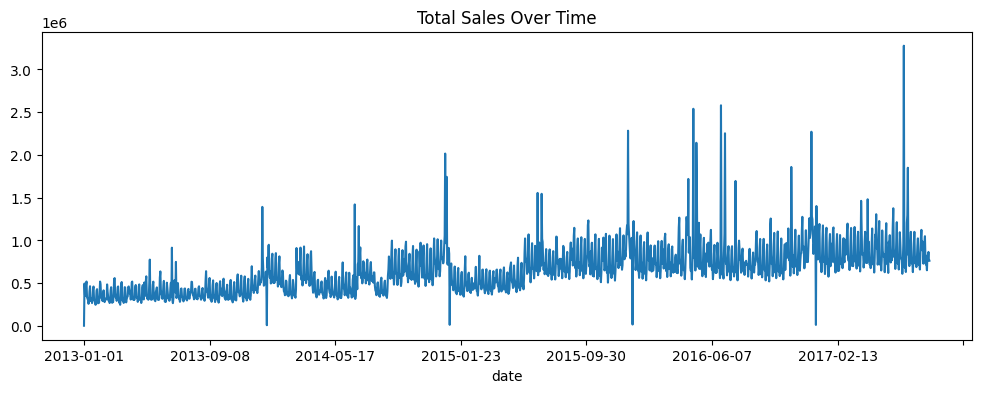

In [111]:
train.groupby('date')['sales'].sum().plot(figsize=(12,4))
plt.title('Total Sales Over Time')
plt.show()


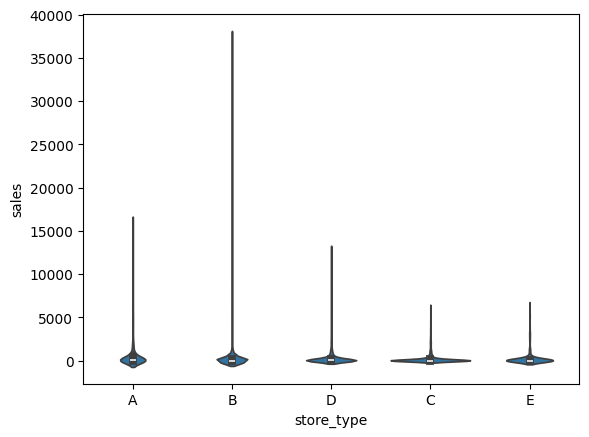

In [112]:
sns.violinplot(data=sample_df, x='store_type', y='sales')
plt.show()


In [113]:
corr_target = sample_df.corr(numeric_only=True)['sales'].sort_values(ascending=False)
print(corr_target)


sales           1.000000
onpromotion     0.439508
transactions    0.201731
id              0.075457
cluster         0.029271
store_nbr       0.021181
transferred     0.010045
is_holiday      0.000122
dcoilwtico     -0.065094
Name: sales, dtype: float64


In [114]:
Q1 = train['sales'].quantile(0.25)
Q3 = train['sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = train[(train['sales'] >= lower) & (train['sales'] <= upper)]


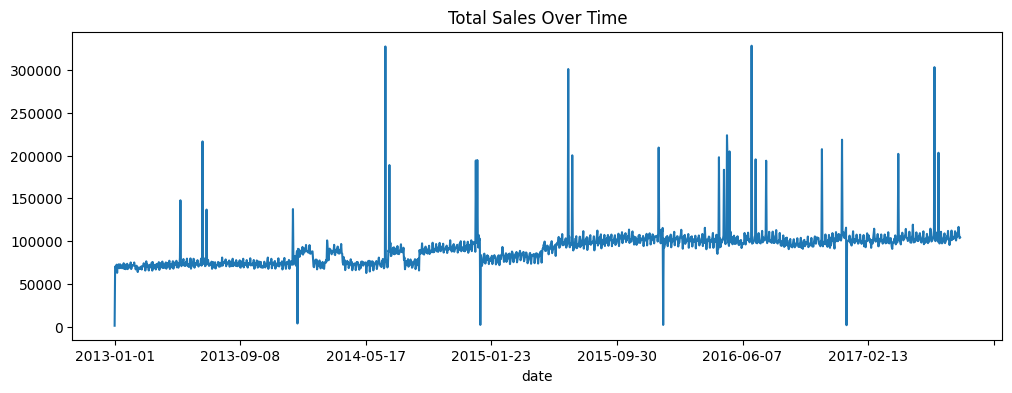

In [115]:
df_no_outliers.groupby('date')['sales'].sum().plot(figsize=(12,4))
plt.title('Total Sales Over Time')
plt.show()


In [116]:
print(test.columns.tolist())
test.head()

['id', 'date', 'store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'city', 'state', 'store_type', 'cluster', 'transferred', 'transactions', 'is_holiday']


,id,date,store_nbr,family,onpromotion,dcoilwtico,city,state,store_type,cluster,transferred,transactions,is_holiday
0,3000888,2017-08-16,1,AUTOMOTIVE,0,46.8,Quito,Pichincha,D,13,0,0.0,0
1194,3002082,2017-08-16,42,CELEBRATION,0,46.8,Cuenca,Azuay,D,2,0,0.0,0
1193,3002081,2017-08-16,42,BREAD/BAKERY,12,46.8,Cuenca,Azuay,D,2,0,0.0,0
1192,3002080,2017-08-16,42,BOOKS,0,46.8,Cuenca,Azuay,D,2,0,0.0,0
1191,3002079,2017-08-16,42,BEVERAGES,19,46.8,Cuenca,Azuay,D,2,0,0.0,0


In [117]:
train = train[
[
'date',
'id',
'store_nbr',
'family',
'city',
'state',
'store_type',
'cluster',
'transactions',
'onpromotion',
'dcoilwtico',
'transferred',
'is_holiday',
'sales'
]
]

test = test[
[
'date',
'id',
'store_nbr',
'family',
'city',
'state',
'store_type',
'cluster',
'transactions',
'onpromotion',
'dcoilwtico',
'transferred',
'is_holiday'
]
]

In [118]:
inputs=list(train.columns)[1:-1]
target='sales'
inputs

['id',
 'store_nbr',
 'family',
 'city',
 'state',
 'store_type',
 'cluster',
 'transactions',
 'onpromotion',
 'dcoilwtico',
 'transferred',
 'is_holiday']

In [119]:
train.head()

,date,id,store_nbr,family,city,state,store_type,cluster,transactions,onpromotion,dcoilwtico,transferred,is_holiday,sales
0,2013-01-01,0,1,AUTOMOTIVE,Quito,Pichincha,D,13,0.0,0,93.14,0,1,0.0
1194,2013-01-01,1194,42,CELEBRATION,Cuenca,Azuay,D,2,0.0,0,93.14,0,1,0.0
1193,2013-01-01,1193,42,BREAD/BAKERY,Cuenca,Azuay,D,2,0.0,0,93.14,0,1,0.0
1192,2013-01-01,1192,42,BOOKS,Cuenca,Azuay,D,2,0.0,0,93.14,0,1,0.0
1191,2013-01-01,1191,42,BEVERAGES,Cuenca,Azuay,D,2,0.0,0,93.14,0,1,0.0


In [120]:
from sklearn.model_selection import train_test_split


In [121]:
train_set, val_set = train_test_split(train, test_size=0.2, random_state=42)


In [122]:
train_inputs=train_set[inputs].copy()
train_target=train_set[target].copy()

In [123]:
val_inputs=val_set[inputs].copy()
val_target=val_set[target].copy()

In [124]:
numeric_cols=train_inputs.select_dtypes(include=np.number).columns.tolist()
categ_cols=train_inputs.select_dtypes('object').columns.tolist()

C:\Users\umman\AppData\Local\Temp\ipykernel_7736\2958763588.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categ_cols=train_inputs.select_dtypes('object').columns.tolist()


In [125]:
numeric_cols

['id',
 'store_nbr',
 'cluster',
 'transactions',
 'onpromotion',
 'dcoilwtico',
 'transferred',
 'is_holiday']

In [126]:
categ_cols

['family', 'city', 'state', 'store_type']

In [127]:
from sklearn.preprocessing import OneHotEncoder

In [128]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [129]:
encoder.fit(train[categ_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [130]:
encoded_cols = list(encoder.get_feature_names_out(categ_cols)) #this get each categ columns unique row

In [131]:
encoded_cols


['family_AUTOMOTIVE',
 'family_BABY CARE',
 'family_BEAUTY',
 'family_BEVERAGES',
 'family_BOOKS',
 'family_BREAD/BAKERY',
 'family_CELEBRATION',
 'family_CLEANING',
 'family_DAIRY',
 'family_DELI',
 'family_EGGS',
 'family_FROZEN FOODS',
 'family_GROCERY I',
 'family_GROCERY II',
 'family_HARDWARE',
 'family_HOME AND KITCHEN I',
 'family_HOME AND KITCHEN II',
 'family_HOME APPLIANCES',
 'family_HOME CARE',
 'family_LADIESWEAR',
 'family_LAWN AND GARDEN',
 'family_LINGERIE',
 'family_LIQUOR,WINE,BEER',
 'family_MAGAZINES',
 'family_MEATS',
 'family_PERSONAL CARE',
 'family_PET SUPPLIES',
 'family_PLAYERS AND ELECTRONICS',
 'family_POULTRY',
 'family_PREPARED FOODS',
 'family_PRODUCE',
 'family_SCHOOL AND OFFICE SUPPLIES',
 'family_SEAFOOD',
 'city_Ambato',
 'city_Babahoyo',
 'city_Cayambe',
 'city_Cuenca',
 'city_Daule',
 'city_El Carmen',
 'city_Esmeraldas',
 'city_Guaranda',
 'city_Guayaquil',
 'city_Ibarra',
 'city_Latacunga',
 'city_Libertad',
 'city_Loja',
 'city_Machala',
 'city_

In [153]:
# for train
train_inputs[encoded_cols] = pd.DataFrame(
    encoder.transform(train_inputs[categ_cols]),
    index=train_inputs.index
)

# for val
val_inputs[encoded_cols] = pd.DataFrame(
    encoder.transform(val_inputs[categ_cols]),
    index=val_inputs.index
)

test[encoded_cols] = pd.DataFrame(
    encoder.transform(test[categ_cols]),
    index=test.index
)

In [133]:
train_inputs.head()

,id,store_nbr,family,city,state,store_type,cluster,transactions,onpromotion,dcoilwtico,...,state_Pastaza,state_Pichincha,state_Santa Elena,state_Santo Domingo de los Tsachilas,state_Tungurahua,store_type_A,store_type_B,store_type_C,store_type_D,store_type_E
1016240,1000202,23,BREAD/BAKERY,Ambato,Tungurahua,D,9,968.0,0,103.840000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2090271,2063541,9,HOME CARE,Quito,Pichincha,B,6,2448.0,3,37.239644,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1750694,1725746,30,FROZEN FOODS,Guayaquil,Guayas,C,3,708.0,13,46.794774,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1779059,1754111,26,PREPARED FOODS,Guayaquil,Guayas,D,10,446.0,0,44.070000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
72115,72115,32,EGGS,Guayaquil,Guayas,C,3,709.0,0,96.908626,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [134]:
from xgboost import XGBRegressor

In [135]:
regressor=XGBRegressor()

In [136]:
regressor.fit(train_inputs[numeric_cols+encoded_cols],train_target)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [137]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = regressor.predict(val_inputs[numeric_cols + encoded_cols])

print("MAE:", mean_absolute_error(val_target, y_pred))
print("RMSE:", root_mean_squared_error(val_target, y_pred))
print("R2:", r2_score(val_target, y_pred))

MAE: 73.65593137137466
RMSE: 239.25374333058514
R2: 0.9527430325828815


In [138]:
residuals = val_target - y_pred
residuals.describe()  # see the distribution of errors

count    610868.000000
mean         -0.084622
std         239.253924
min       -6708.079590
25%         -23.964255
50%          -1.766605
75%          14.782146
max       32780.476781
Name: sales, dtype: float64

Here's what this tells you:
The good:

Mean ≈ 0.10 → almost no systematic bias, the model isn't consistently over or underestimating
50% (median) = -2.10 → half your predictions are within just 2 units, very good
25%-75% range = -23 to +15 → the majority of predictions are quite close

The concern:

Min = -5,791 → at worst, your model overestimated by 5,791 units
Max = +71,815 → at worst, your model underestimated by 71,815 units
Std = 264 → this matches your RMSE exactly (as expected), confirming those extreme outliers are dragging it up

Overall picture:

Your model is actually performing very well for most predictions (median error of just -2.1)
But there are a handful of extreme cases where it's way off, particularly the max of 71,815
These outliers are what's causing the big gap between your MAE (73) and RMSE (264)



In [139]:
# see the worst predictions
worst = val_inputs[numeric_cols+categ_cols].copy()
worst['actual'] = val_target.values
worst['predicted'] = y_pred
worst['residual'] = residuals.values
worst.nlargest(10, 'residual')  # 10 worst underestimates
worst.nsmallest(10, 'residual')  # 10 worst overestimates

,id,store_nbr,cluster,transactions,onpromotion,dcoilwtico,transferred,is_holiday,family,city,state,store_type,actual,predicted,residual
821004,812094,44,5,4366.0,0,99.600000,0,0,PRODUCE,Quito,Pichincha,A,10.000,6718.079590,-6708.079590
2641002,2594670,11,6,3384.0,150,53.459886,0,1,GROCERY I,Cayambe,Pichincha,B,8407.872,13958.491211,-5550.619211
657042,648132,44,5,5085.0,0,98.170000,0,1,GROCERY I,Quito,Pichincha,A,6409.000,11937.784180,-5528.784180
657093,648183,45,11,4509.0,0,98.170000,0,1,PRODUCE,Quito,Pichincha,A,49.000,5438.734375,-5389.734375
2624493,2579943,48,14,4615.0,79,51.440000,0,1,BEVERAGES,Quito,Pichincha,A,4604.000,9864.122070,-5260.122070
1082430,1066392,3,8,3400.0,0,94.302527,0,0,PRODUCE,Quito,Pichincha,D,30.000,5123.174316,-5093.174316
1306956,1287870,44,5,5693.0,18,54.590000,0,1,GROCERY I,Quito,Pichincha,A,9609.000,14459.474609,-4850.474609
818694,809784,3,8,3256.0,0,99.690000,0,1,PRODUCE,Quito,Pichincha,D,0.000,4844.893555,-4844.893555
646515,637605,49,11,5428.0,0,98.870000,0,1,GROCERY I,Quito,Pichincha,A,6660.000,11453.930664,-4793.930664
821037,812127,45,11,3645.0,0,99.600000,0,0,PRODUCE,Quito,Pichincha,A,4.000,4796.748047,-4792.748047


In [140]:
# see how represented these are in training
train_set[(train_set['state'] == 'Pichincha') & (train_set['store_type'] == 'A')].shape

(271268, 14)

In [141]:
val_set[(val_set['state'] == 'Pichincha') & (val_set['store_type'] == 'A')].shape

(68101, 14)

In [142]:
train_set[(train_set['state'] == 'Pichincha') & (train_set['store_type'] == 'A')]['sales'].describe()

count    271268.000000
mean        870.615836
std        2160.895992
min           0.000000
25%           3.000000
50%          48.000000
75%         635.000000
max       46271.000000
Name: sales, dtype: float64

In [143]:
train_set[(train_set['state'] == 'Pichincha') & 
          (train_set['store_type'] == 'A')].groupby('store_nbr')['sales'].mean().nlargest(10)

store_nbr
44    1114.483343
45     986.884666
47     925.625757
49     786.746370
46     762.654962
48     647.367032
Name: sales, dtype: float64

In [144]:
train_set[(train_set['state'] == 'Pichincha') & 
          (train_set['store_type'] == 'A')].groupby('family')['sales'].mean().nlargest(10)

family
GROCERY I        8580.841093
BEVERAGES        5862.737954
PRODUCE          3730.575451
CLEANING         2256.922211
DAIRY            1863.933657
POULTRY          1073.418848
BREAD/BAKERY     1025.831254
MEATS             992.481353
PERSONAL CARE     625.571741
DELI              617.590471
Name: sales, dtype: float64

In [145]:
train_set[(train_set['state'] == 'Pichincha') & 
          (train_set['store_type'] == 'A')].groupby('cluster')['sales'].mean().nlargest(10)

cluster
5     1114.483343
11     887.134746
14     778.436653
Name: sales, dtype: float64

In [146]:
# see if worst predictions are concentrated in these families
worst.nlargest(10, 'residual')['family'].value_counts()

family
GROCERY I    6
BEVERAGES    3
CLEANING     1
Name: count, dtype: int64

In [147]:
train_set['promo_bucket'] = pd.cut(train_set['onpromotion'], 
                                    bins=[0, 10, 50, 100, 200, 999999],
                                    labels=['very low', 'low', 'medium', 'high', 'very high'])

train_set[(train_set['state'] == 'Pichincha') & 
          (train_set['store_type'] == 'A') &
          (train_set['family'] == 'GROCERY I')].groupby('promo_bucket')['sales'].mean()

promo_bucket
very low      8033.381399
low           9199.577423
medium       10004.544437
high         11466.171806
very high    11604.000000
Name: sales, dtype: float64

In [148]:
train_set[train_set['sales'] > 50000].shape  # how many extreme values exist?

(0, 15)

In [149]:
train_set[train_set['sales'] > 50000][['store_nbr', 'family', 'state', 'sales']]

,store_nbr,family,state,sales


now ill just go back and remove values that are above 50000 to remove the uncertainty its causing in the model.

In [159]:
y_pred = regressor.predict(test[numeric_cols + encoded_cols])
test['sales'] = y_pred
test[numeric_cols + categ_cols + ['sales']].head()

,id,store_nbr,cluster,transactions,onpromotion,dcoilwtico,transferred,is_holiday,family,city,state,store_type,sales
0,3000888,1,13,0.0,0,46.8,0,0,AUTOMOTIVE,Quito,Pichincha,D,-18.663588
1194,3002082,42,2,0.0,0,46.8,0,0,CELEBRATION,Cuenca,Azuay,D,-24.804611
1193,3002081,42,2,0.0,12,46.8,0,0,BREAD/BAKERY,Cuenca,Azuay,D,470.589722
1192,3002080,42,2,0.0,0,46.8,0,0,BOOKS,Cuenca,Azuay,D,-19.789013
1191,3002079,42,2,0.0,19,46.8,0,0,BEVERAGES,Cuenca,Azuay,D,2204.941650
